In [22]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

#   On recupère les index des plus grandes avalanches enregistrer pour chaque valeur de dissipation

In [39]:
Tfolderpath =["/data1/DATA_Duplat/Brut/Ava_track/Av6n{}".format(i) for i in range(1,8)]

for folderpath in Tfolderpath:
    file = f"{folderpath}/shape_outputB10.txt"

    L1 = read_parameters(folderpath)[0]
    L2 = read_parameters(folderpath)[1]
    data = []
    Nava = []
    nbava = 200

    with open(file) as f:
        
        for i, line in enumerate(f):
            if line.startswith("#"):
                continue
            col = line.strip().split()[3:]
            id = line.strip().split()[0]
            col = np.array(col, dtype=int)
            y, x = coorno(col, L1)
            """ y = (L1-1) - y """
            
            coo = np.column_stack((x, y))
            data.append(coo.tolist())
            Nava.append(id)
            if i == nbava:
                break

    ava_len = [len(data[i]) for i in range(len(data))]
    id = ava_len.index(max(ava_len))
    print(id, Nava[id], len(data[id]))

95 1104 62370
89 24621 28476
62 45887 21739
6 9317 15241
72 555979 12895
141 5883073 9254
147 379046476 3476


#   On identifie le patch et on l'isole

In [53]:
folderpath ="/data1/DATA_Duplat/Brut/Ava_track/Av6n6"
file = f"{folderpath}/shape_outputB10.txt"

L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]
data = []
Nava = []
nbava = 200

with open(file) as f:
    
    for i, line in enumerate(f):
        if line.startswith("#"):
            continue
        col = line.strip().split()[3:]
        id = line.strip().split()[0]
        col = np.array(col, dtype=int)
        y, x = coorno(col, L1)
        """ y = (L1-1) - y """
        
        coo = np.column_stack((x, y))
        data.append(coo.tolist())
        Nava.append(id)
        if i == nbava:
            break
        
id = 141
Noava = 5883073
sys = np.loadtxt("/data1/DATA_Duplat/Brut/Ava_track/Av6n6/Snapshots/nav{}_outputB.txt".format(Noava)).reshape(L1, L2)

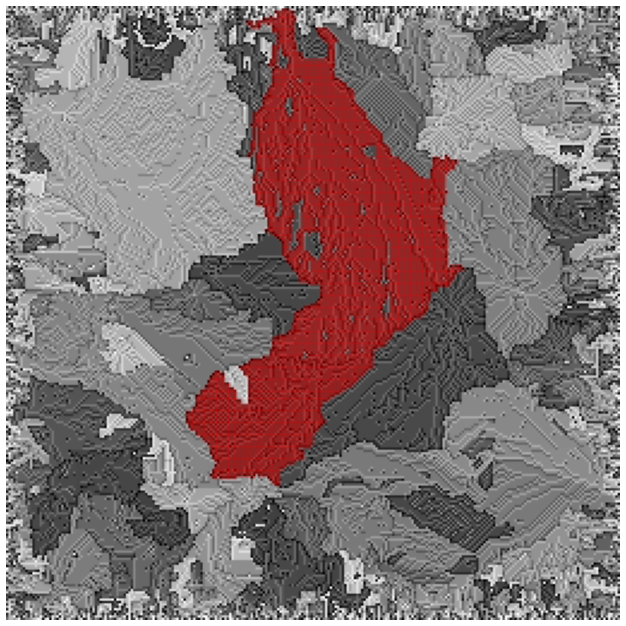

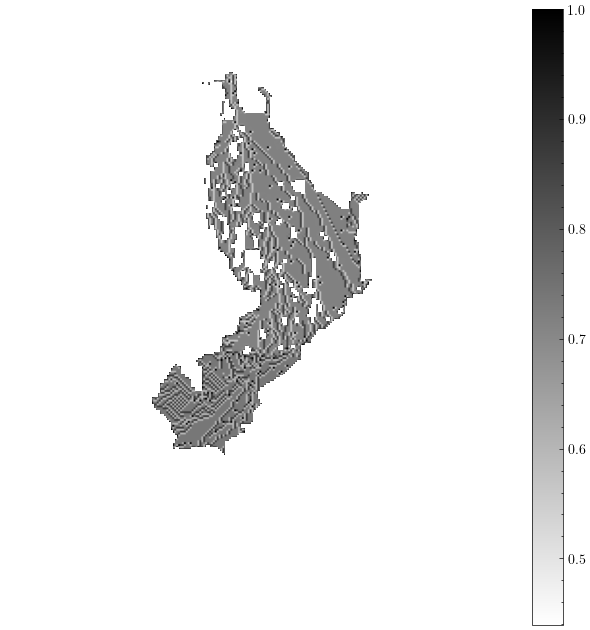

In [ ]:
id = 141
Noava = 5883073
sys = np.loadtxt("/data1/DATA_Duplat/Brut/Ava_track/Av6n6/Snapshots/nav{}_outputB.txt".format(Noava)).reshape(L1, L2)
ava = np.array(data[id])

y = ava[:,0]
x = ava[:, 1]
fig, ax = plt.subplots(figsize = (8,8))
ax.imshow(sys, cmap = "binary")
ax.scatter(x, y, c = 'r', alpha = 0.1, s = 10)
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.set_axis_off()

mask = np.zeros_like(sys, dtype = bool)
mask[y,x] = True
sysbis = np.where(mask, sys, np.nan)
# sysbis[mask]

fig, ax = plt.subplots(figsize = (8,8))
pos = ax.imshow(sysbis, cmap = "binary")
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.set_axis_off()
ax.set_axis_off()
fig.colorbar(pos, ax=ax)


#   Find the distribution and extract a new one from it

In [55]:
bins = np.linspace(0,1,50)
histo, bins = np.histogram(sysbis, bins = bins)
pdf = histo/sum(histo)

new_z = np.random.choice(bins[:-1], size = L1*L2 ,replace=True ,p=pdf)

new_histo, _ = np.histogram(new_z, bins = bins)
print(min(new_z), max(new_z))

0.42857142857142855 0.9795918367346939


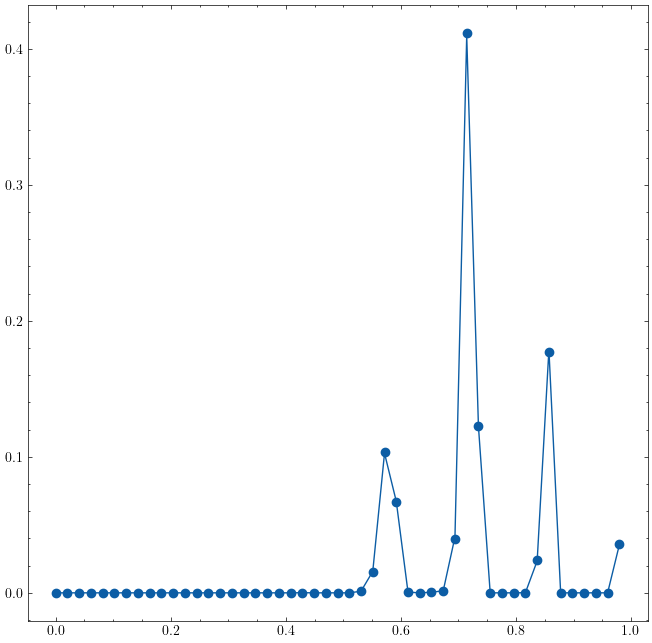

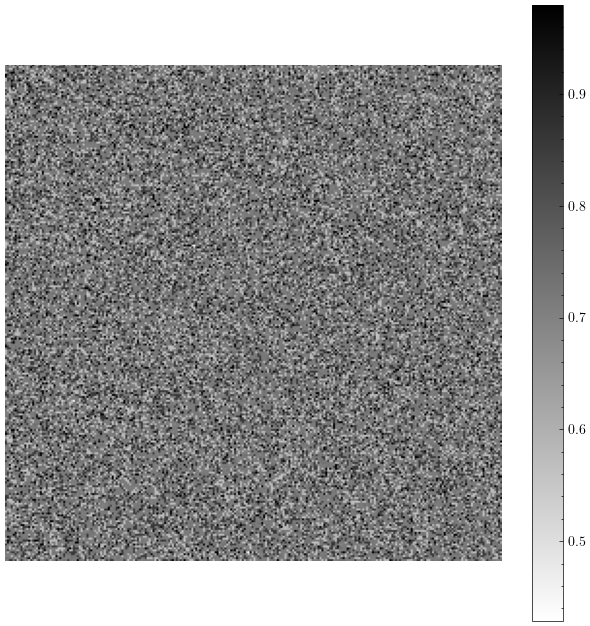

In [56]:
fig, ax = plt.subplots(figsize = (8,8))
ax.plot(bins[:-1], histo/sum(histo))
ax.scatter(bins[:-1], new_histo/sum(new_histo))
plt.show()

newsys = new_z.reshape(L1,L2)
fig, ax = plt.subplots(figsize = (8, 8))
pos =ax.imshow(newsys, cmap= 'binary')
ax.set_axis_off()
fig.colorbar(pos, ax=ax)

plt.show()


#   Redraw values from the conservative system to match the patch distribution

In [44]:
L1 =256
L2 =256

data = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n1/Snapshots/nav100000000_outputB.txt", comments = "#")
sys = data.reshape(L1, L2).T
sysbis = np.copy(sys)
mask = sys<=0.2
sysbis[mask] = 0.5820707070707072

mask = ((sys>0.2) & (sys<=0.8))
sysbis[mask] = 0.7070707070707072

mask = (sys>0.8)
sysbis[mask] = 0.8320707070707072

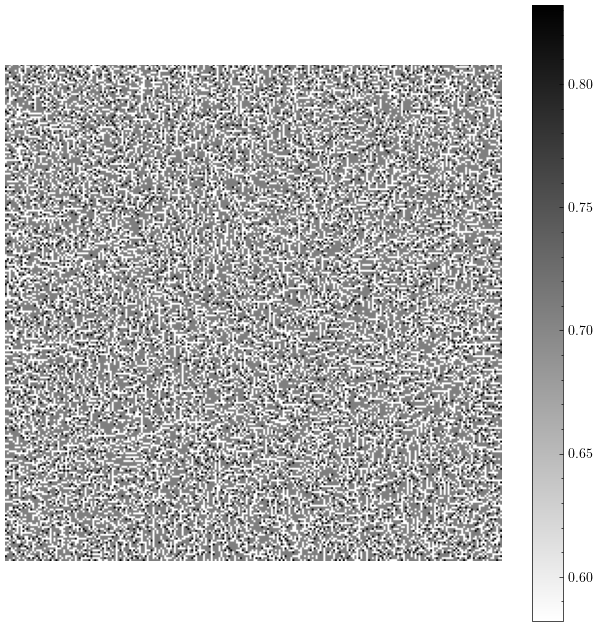

In [45]:
fig, ax = plt.subplots(figsize = (8,8))
pos = ax.imshow(sysbis, cmap = 'binary')
ax.set_axis_off()
fig.colorbar(pos, ax=ax)

#   Test creation patch

In [154]:
data = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n1/Snapshots/nav100000000_outputB.txt", comments = "#")
L1 = L2 = 256

sys = data.reshape(L1, L2).T
sysbis = np.copy(sys)
mask = sys<=0.2
id0 = np.argwhere(mask)

sysbis[mask] = 0
mask = ((sys>0.2) & (sys<=0.5))
sysbis[mask] = 1
id1 = np.argwhere(mask)

mask = ((sys>0.5) & (sys<=0.8))
sysbis[mask] = 2
id2 = np.argwhere(mask)

mask = (sys>0.8)
sysbis[mask] = 3
id3 = np.argwhere(mask)

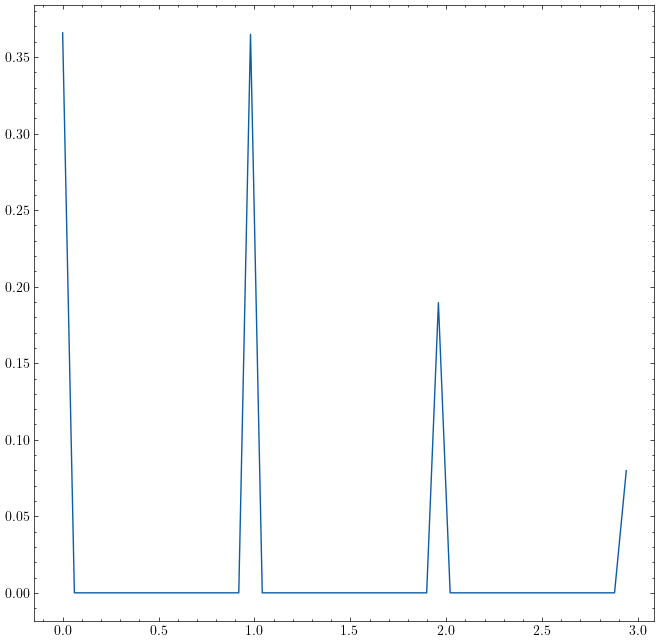

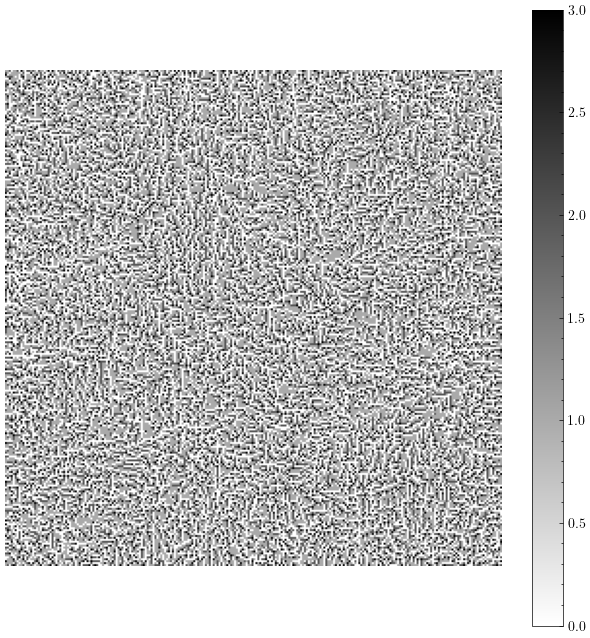

In [155]:
bins  = np.linspace(0,3,50)
histo, _ = np.histogram(sysbis, bins = bins)

fig, ax = plt.subplots(figsize = (8,8))
ax.plot(bins[:-1], histo/sum(histo))
plt.show()

fig, ax = plt.subplots(figsize = (8,8))
pos = ax.imshow(sysbis, cmap = 'binary')
ax.set_axis_off()
fig.colorbar(pos, ax=ax)
plt.show()

In [156]:
flatgrid = sysbis.flatten()
lenid0_sites = np.argwhere(flatgrid==0)[:, 0]
id_swap  = np.random.choice(lenid0_sites, size = int(1*len(lenid0_sites)/2) ,replace=False)
x, y = np.unravel_index(id_swap, (L1, L2))

sysbis[x, y] = 1

flatgrid = sysbis.flatten()
lenid3_sites = np.argwhere(flatgrid==3)[:, 0]
id_swap  = np.random.choice(lenid0_sites, size = int(len(lenid3_sites)/2) ,replace=False)
x, y = np.unravel_index(id_swap, (L1, L2))

sysbis[x, y] = 1

/tmp/ipykernel_3723034/2129827701.py:5: DeprecationWarning: Please use `label` from the `scipy.ndimage` namespace, the `scipy.ndimage.measurements` namespace is deprecated.
  lw, num = measurements.label(mask)
/tmp/ipykernel_3723034/2129827701.py:10: DeprecationWarning: Please use `sum` from the `scipy.ndimage` namespace, the `scipy.ndimage.measurements` namespace is deprecated.
  area = measurements.sum(mask, lw, index=arange(lw.max() + 1))


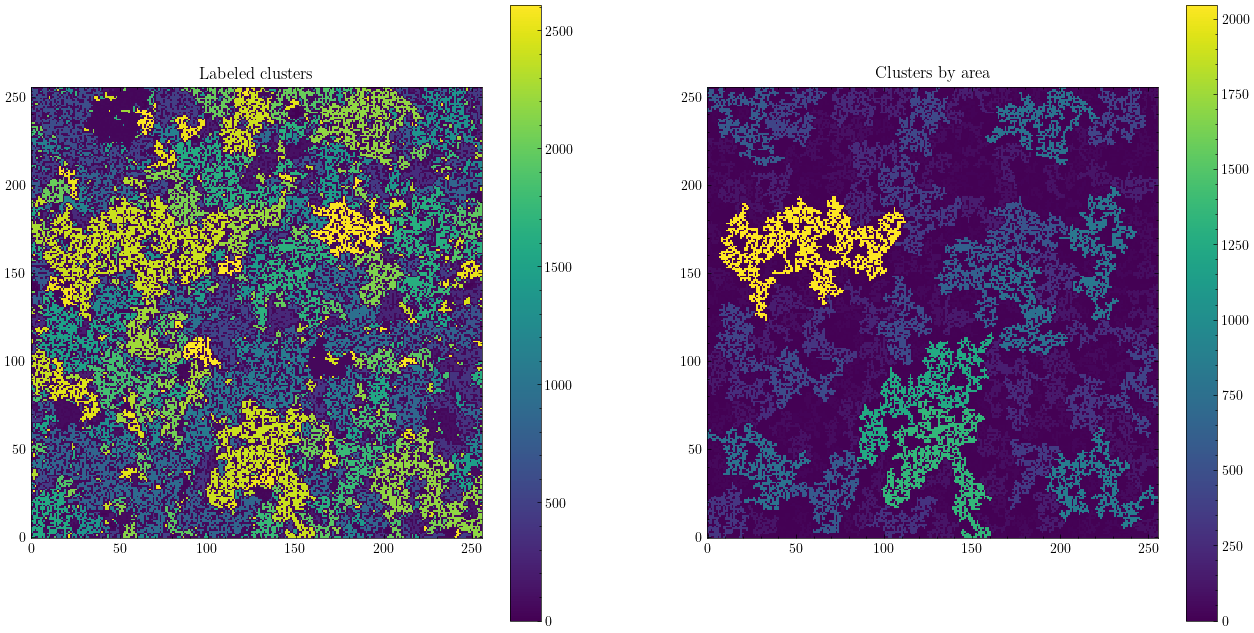

In [157]:
from pylab import *
from scipy.ndimage import measurements

mask = sysbis == 1
lw, num = measurements.label(mask)
b = arange(lw.max() + 1)
shuffle(b)
shuffledLw = b[lw]

area = measurements.sum(mask, lw, index=arange(lw.max() + 1))
areaImg = area[lw]

fig, (ax1,ax2) = plt.subplots(1,2,figsize = (16,8))
pos1 = ax1.imshow(shuffledLw, origin='lower', interpolation='nearest')
fig.colorbar(pos1, ax=ax1)
pos2 = ax2.imshow(areaImg, origin='lower', interpolation='nearest')
fig.colorbar(pos2, ax=ax2)

ax1.set_title("Labeled clusters")
ax2.set_title("Clusters by area")

plt.show()

In [158]:
import random 
sysbis[sysbis == 0] = random.gauss(0.5820707070707072, 0.02)

sysbis[sysbis == 1] = random.gauss(0.7070707070707072, 0.02)
sysbis[sysbis == 2] = random.gauss(0.8320707070707072, 0.02)
sysbis[sysbis == 3] = random.gauss(0.9570707070707072, 0.02)

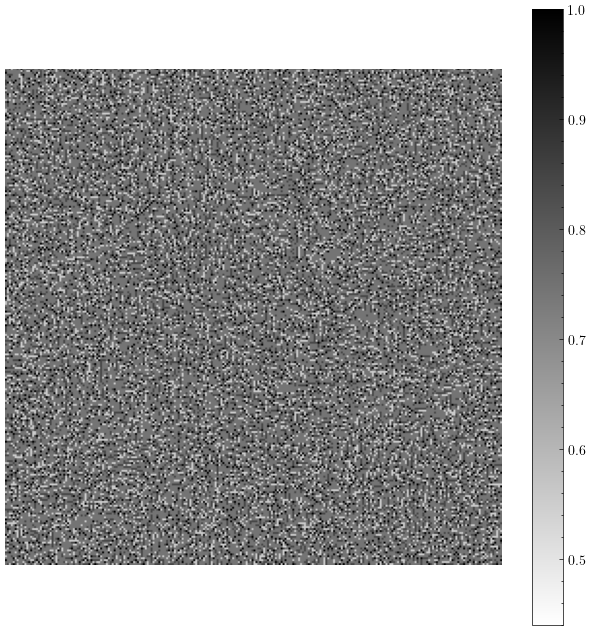

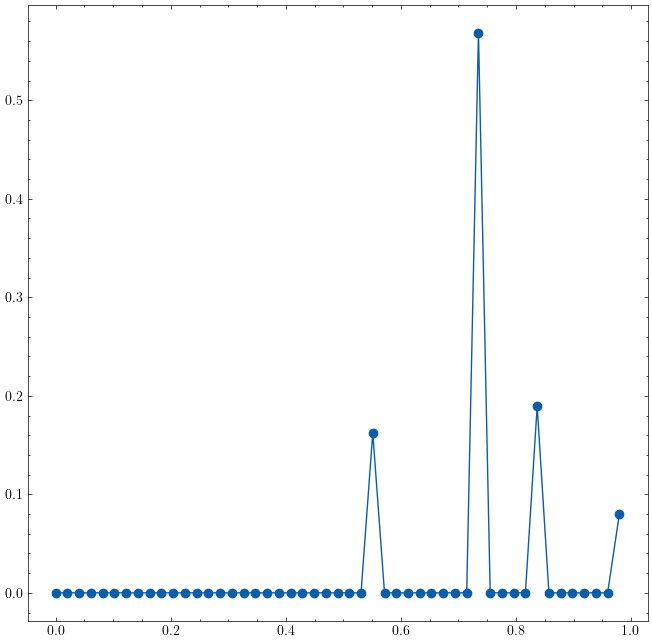

In [159]:
fig, ax = plt.subplots(figsize = (8,8))
pos = ax.imshow(sysbis, cmap = 'binary', vmin = 0.44, vmax = 1)
ax.set_axis_off()
fig.colorbar(pos, ax=ax)
plt.show()


bins  = np.linspace(0,1,50)
histo, _ = np.histogram(sysbis, bins = bins)

fig, ax = plt.subplots(figsize = (8,8))
ax.plot(bins[:-1], histo/sum(histo), marker = 'o')
plt.show()

In [7]:
def random_border_point(L, choice = ["top", "bottom", "left", "right"]):
    side = random.choice(choice)

    if side == "top":
        return random.randint(1, L-2), L-2, -np.pi/2
    if side == "bottom":
        return random.randint(1, L-2), 1, np.pi/2
    if side == "left":
        return 1, random.randint(1, L-2), 0
    if side == "right":
        return L-2, random.randint(1, L-2), np.pi
    
def lim_angle(angle, angle_ref, max_dev=np.pi/4):
    d = np.arctan2(np.sin(angle - angle_ref), np.cos(angle - angle_ref))
    d = np.clip(d, -max_dev, max_dev)
    return angle_ref + d
    
def grow(x, y, angle, depth, angle_noise, p_branch, angle_ref):
    if depth == 0:
        return

    cx, cy = x, y

    branch_length = random.randint(2, 40)
    for _ in range(branch_length):

        # Courbure locale
        angle += np.random.normal(0, angle_noise)
        
        angle = lim_angle(angle, angle_ref, max_dev=3*np.pi/4)
        
        dx = int(np.round(np.cos(angle)))
        dy = int(np.round(np.sin(angle)))

        cx += dx
        cy += dy

        # Limites du réseau
        if cx < 1 or cx >= L-1 or cy < 1 or cy >= L-1:
            return

        # Si la cellule est déjà occupée, tente de se détourner
        if grid[cy, cx] in [0,3]  :
            # Petite variation d'angle pour contourner
            angle += np.random.uniform(-np.pi/3, np.pi/3)
            dx = int(np.round(np.cos(angle)))
            dy = int(np.round(np.sin(angle)))
            cx += dx
            cy += dy

            # Si après détour la cellule est encore occupée ou hors limites, arrêter
            if (cx < 1 or cx >= L-1 or cy < 1 or cy >= L-1 or grid[cy, cx] in [0,3]):
                return
            break
        
        # Marque la cellule
        grid[cy, cx] = 0

        # Branching condition
        if np.random.rand() < p_branch:
            new_angle = angle + np.random.uniform(-np.pi/4, np.pi/4)
            grow(cx, cy, new_angle, depth - 1, angle_noise, p_branch, angle_ref)

    # Continue main branch
    angle += np.random.normal(0, angle_noise)
    grow(cx, cy, angle, depth - 1, angle_noise, p_branch, angle_ref)
    

[    0     1     2 ... 65533 65534 65535]


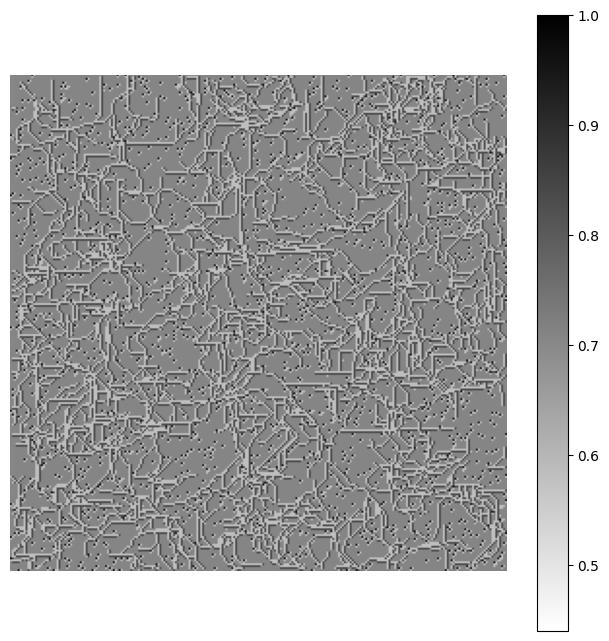

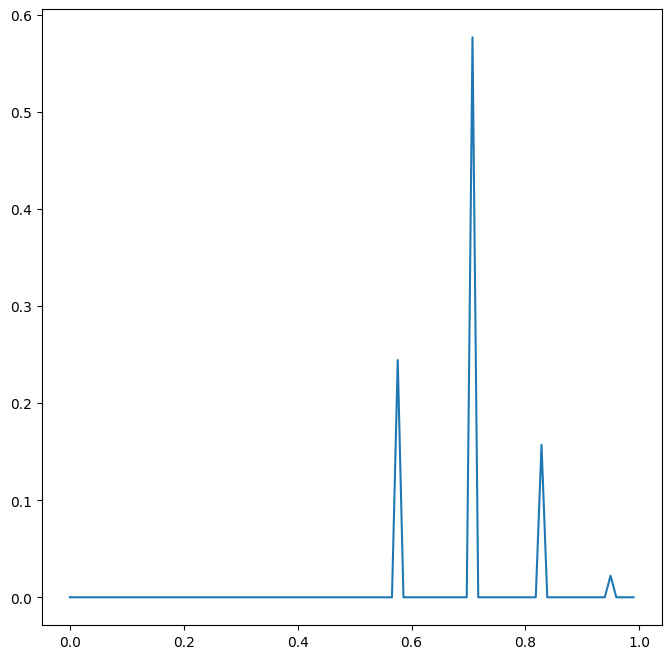

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
# -----------------------------
# Parameters
# -----------------------------
L = 256                 # lattice size
center = L // 2
max_depth = 5            # branching depth
# branch_length = 15      # length of each branch
p_branch = 0.08         # probability to branch
angle_noise = 0.3     # angular disorder


# -----------------------------
# Start growth
# -----------------------------
choice = ["top", "bottom", "left", "right"]

grid = np.ones((L, L), dtype=int)

count = 0
while True:
    x0, y0 = np.unravel_index(random.randint(0,L**2-1), (L, L))
    angle0 = random.uniform(0,np.pi)
    
    # x0, y0, angle0 = random_border_point(L, choice)
    grid[y0, x0] = 0
    grow(x0,y0, angle0, max_depth, angle_noise, p_branch, angle0)
    
    # fig, ax = plt.subplots(figsize=(8, 8))
    # pos = ax.imshow(grid, cmap="binary", vmin = 0.44, vmax = 1)
    # ax.set_axis_off()
    # fig.colorbar(pos, ax=ax)
    # plt.show()
    
    # count+=1
    if (0.2<(np.sum((grid == 0) | (grid == 4))/L**2)<0.3) | (count == 2):
        break 

flatgrid = grid.flatten()
id_emptysites = np.argwhere(flatgrid==1)[:, 0]
print(np.argwhere(flatgrid==1)[:,0])
id_singlesite = np.random.choice(id_emptysites, size=int(0.03*L**2), replace=False)
x, y = np.unravel_index(id_singlesite, (L, L))

mask1 = x!= L-1
mask2 = y != L-1
grid[x, y] = 3
grid[x[mask1]+1, y[mask1]] = 4
grid[x[mask2], y[mask2]+1] = 4


new_grid = grid.astype(float)

coo = np.argwhere(grid == 0)
x= coo[:,0]
y= coo[:,1]

mask3 = y != L-1
x = x[mask3]
y = y[mask3]

for i, (xp, yp) in enumerate(zip(x, y)):
    if not np.any(np.all(coo == [xp, yp+1], axis=1)):
        new_grid[xp, yp+1] = 2
    elif not np.any(np.all(coo == [xp+1, yp], axis=1)):
        new_grid[xp+1, yp] = 2

new_grid[new_grid == 0] = 0.5820707070707072
new_grid[new_grid == 4] = 0.5820707070707072
new_grid[new_grid == 1] = 0.7070707070707072
new_grid[new_grid == 2] = 0.8320707070707072
new_grid[new_grid == 3] = 0.9570707070707072

# -----------------------------
# Visualization
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
pos = ax.imshow(new_grid, cmap="binary", vmin = 0.44, vmax = 1)
ax.set_axis_off()
fig.colorbar(pos, ax=ax)
plt.show()

bins = np.linspace(0,1,100)
histo, bins = np.histogram(new_grid, bins = bins)
fig, ax = plt.subplots(figsize = (8,8))
ax.plot(bins[:-1], histo/np.sum(histo))
plt.show()


[    2     3     4 ... 65531 65533 65534]


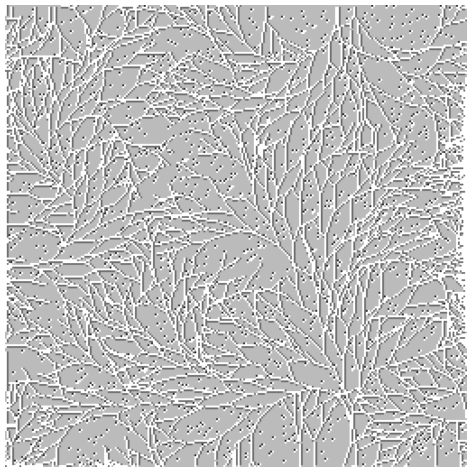

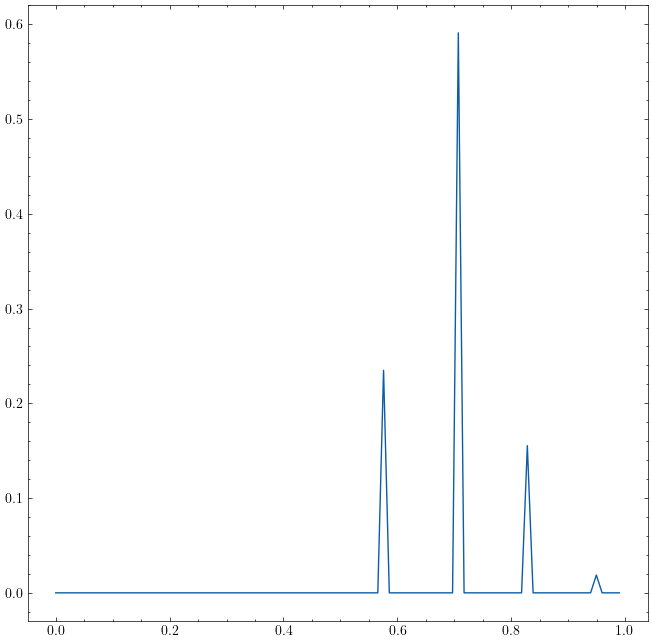

In [ ]:
import random



def draw_line(img, x1, y1, x2, y2):
    """Trace une ligne simple (interpolation linéaire)."""
    length = int(max(abs(x2 - x1), abs(y2 - y1)))
    for i in range(length + 1):
        t = i / length
        if t>0:
            x = int(x1 + t * (x2 - x1))
            y = int(y1 + t * (y2 - y1))
            if 0 <= x < W and 0 <= y < H :
                if img[y, x] == 0:
                    return False
                img[y, x] = 0 
            
    return True



def drawTree(x1, y1, angle, depth, min_len = 5, max_len = 15, p_branch = 0.00, ifork_angle = 20):

    if depth > 0:
        
        branch_length = random.randint(min_len, max_len)
        x2 = x1 + math.cos(math.radians(angle))  * branch_length
        branch_length = random.randint(min_len, max_len)
        y2 = y1 + math.sin(math.radians(angle))  * branch_length

        if draw_line(image, x1, y1, x2, y2):
            if np.random.rand() > p_branch:
                drawTree(x2, y2, angle - ifork_angle, depth - 1, ifork_angle=ifork_angle)
            if np.random.rand() > p_branch:
                drawTree(x2, y2, angle + ifork_angle, depth - 1, ifork_angle=ifork_angle)


def random_border_point(L, choice = ["top", "bottom", "left", "right"]):
    side = random.choice(choice)

    if side == "top":
        return random.randint(1, L-2), 0, 90
    if side == "bottom":
        return random.randint(1, L-2), 256, -90
    if side == "left":
        return 256, random.randint(1, L-2), 180, 
    if side == "right":
        return 0, random.randint(1, L-2), 0


H, W = 256, 256
image = np.ones((H, W), dtype=float)

L = 256
# x0,y0, angle0= random_border_point(L)
# x0 = 128
# y0 = 256
# angle0 = -90
ifork_angle = 20
depth0 = 20
p_branch = 0.0

c = 0
while True:
    
    x0,y0, angle0= random_border_point(L)
    drawTree(x0, y0, angle0, depth0, p_branch = p_branch)
    # if c %10 ==0 and c < 50:
    #     fig, ax = plt.subplots(figsize = (6,6))
    #     plt.imshow(image, cmap='binary')
    #     plt.axis('off')
    #     plt.show()
    c += 1
    if (0.2<(np.sum(image == 0)/L**2)<0.3): 
        break


# Duplicate the branches
coo = np.argwhere(image == 0)
x= coo[:,0]
y= coo[:,1]

mask1 = y != L-1
x = x[mask1]
y = y[mask1]
mask2 = x != L-1
x = x[mask2]
y = y[mask2]

for i, (xp, yp) in enumerate(zip(x, y)):
    if not np.any(np.all(coo == [xp, yp+1], axis=1)):
        image[xp, yp+1] = 2
    elif not np.any(np.all(coo == [xp+1, yp], axis=1)):
        image[xp+1, yp] = 2
      
#Add random sites
p_type4 = 0.02
flatimage  = image.flatten()
id_emptysites = np.argwhere(flatimage==1)[:, 0]
print(id_emptysites[:])
id_singlesite = np.random.choice(id_emptysites, size=int(p_type4*L**2), replace=False)
x, y = np.unravel_index(id_singlesite, (L, L))

mask1 = x!= L-1
x = x[mask1]
y = y[mask1]
mask2 = y != L-1
x = x[mask2]
y = y[mask2]
image[x, y] = 3

#coupled them with Type 1 sites
image[x+1, y] = 0
image[x, y+1] = 0


image[image == 0] = 0.5820707070707072
image[image == 1] = 0.7070707070707072
image[image == 2] = 0.8320707070707072
image[image == 3] = 0.9570707070707072
        
fig, ax = plt.subplots(figsize = (6,6))
plt.imshow(image, cmap='binary', vmin = 0.6, vmax = 1)
plt.axis('off')
plt.show()

bins = np.linspace(0,1,100)
histo, bins = np.histogram(image, bins = bins)
fig, ax = plt.subplots(figsize = (8,8))
ax.plot(bins[:-1], histo/np.sum(histo))
plt.show()


#   Comparaison perco analysis, patch et patch artificiel 

In [ ]:

from pylab import *
import scipy.ndimage

def draw_line(img, x1, y1, x2, y2, L):
    """Trace une ligne simple (interpolation linéaire)."""
    length = int(max(abs(x2 - x1), abs(y2 - y1)))
    for i in range(length + 1):
        t = i / length
        if t>0:
            x = int(x1 + t * (x2 - x1))
            y = int(y1 + t * (y2 - y1))
            if 0 <= x < L and 0 <= y < L :
                if img[y, x] == 0:
                    return False
                img[y, x] = 0 
            
    return True



def drawTree(img, x1, y1, angle, depth, L, min_len = 5, max_len = 15, p_branch = 0.00, ifork_angle = 20):

    if depth > 0:
        
        branch_length = np.random.randint(min_len, max_len)
        x2 = x1 + math.cos(math.radians(angle))  * branch_length
        branch_length = np.random.randint(min_len, max_len)
        y2 = y1 + math.sin(math.radians(angle))  * branch_length

        if draw_line(img, x1, y1, x2, y2, L):
            if np.random.rand() > p_branch:
                drawTree(img, x2, y2, angle - ifork_angle, depth - 1, L, ifork_angle=ifork_angle)
            if np.random.rand() > p_branch:
                drawTree(img, x2, y2, angle + ifork_angle, depth - 1, L, ifork_angle=ifork_angle)


def random_border_point(L, side = ["top", "bottom", "left", "right"]):
    side = np.random.choice(side)

    if side == "top":
        return np.random.randint(1, L-2), 0, 90
    if side == "bottom":
        return np.random.randint(1, L-2), 256, -90
    if side == "left":
        return 256, np.random.randint(1, L-2), 180, 
    if side == "right":
        return 0, np.random.randint(1, L-2), 0
    
def artificial_patch(L = 256, ifork_angle = 20, depth0 = 20, p_branch = 0.0):
    image = np.ones((L, L), dtype=float)
    c = 0
    while True:
        
        x0,y0, angle0= random_border_point(L)
        drawTree(image, x0, y0, angle0, depth0, L, p_branch = p_branch)
        c += 1
        if (0.2<(np.sum(image == 0)/L**2)<0.3): 
            break


    # Duplicate the branches
    coo = np.argwhere(image == 0)
    x= coo[:,0]
    y= coo[:,1]

    mask1 = y != L-1
    x = x[mask1]
    y = y[mask1]
    mask2 = x != L-1
    x = x[mask2]
    y = y[mask2]

    for i, (xp, yp) in enumerate(zip(x, y)):
        if not np.any(np.all(coo == [xp, yp+1], axis=1)):
            image[xp, yp+1] = 2
        elif not np.any(np.all(coo == [xp+1, yp], axis=1)):
            image[xp+1, yp] = 2
        
    #Add random sites
    p_type4 = 0.02
    flatimage  = image.flatten()
    id_emptysites = np.argwhere(flatimage==1)[:, 0]
    # print(id_emptysites[:])
    id_singlesite = np.random.choice(id_emptysites, size=int(p_type4*L**2), replace=False)
    x, y = np.unravel_index(id_singlesite, (L, L))

    mask1 = x!= L-1
    x = x[mask1]
    y = y[mask1]
    mask2 = y != L-1
    x = x[mask2]
    y = y[mask2]
    image[x, y] = 3

    #coupled them with Type 1 sites
    image[x+1, y] = 0
    image[x, y+1] = 0


    image[image == 0] = 0.5820707070707072
    image[image == 1] = 0.7070707070707072
    image[image == 2] = 0.8320707070707072
    image[image == 3] = 0.9570707070707072

    return image



def perco_analysis(image):
    mask1 = ((image > 0.5) & (image <= 0.65))
    mask2 = ((image > 0.65) & (image <= 0.78))
    mask3 = ((image > 0.8) & (image <= 0.9))
    mask4 = ((image > 0.9))

    masks = [mask1, mask2, mask3, mask4]
    
    mean_area = np.zeros(len(masks))

    matrix = np.ones((3, 3), dtype=int)

    for i, mask in enumerate(masks):

        lw, num = scipy.ndimage.label(mask, structure=matrix)
        area = scipy.ndimage.sum(mask, lw, index=np.arange(lw.max() + 1))

        mean_area[i] = np.mean(area[1:])
            
    return mean_area
            



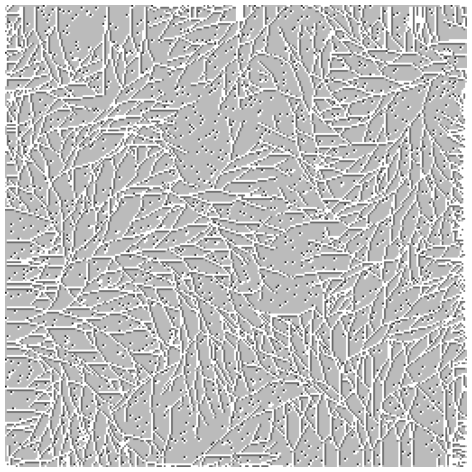

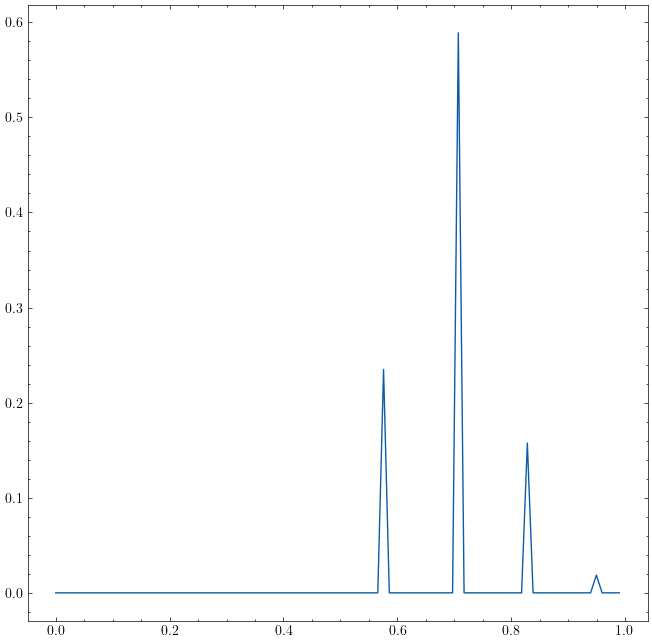

In [ ]:
L = 256
image = artificial_patch()
# fig, ax = plt.subplots(figsize = (6,6))
# plt.imshow(image, cmap='binary', vmin = 0.6, vmax = 1)
# plt.axis('off')
# plt.show()

# bins = np.linspace(0,1,100)
# histo, bins = np.histogram(image, bins = bins)
# fig, ax = plt.subplots(figsize = (8,8))
# ax.plot(bins[:-1], histo/np.sum(histo))
# plt.show()


26.63840830449827
67.70877192982456
5.117501239464551
1.0461933276304534


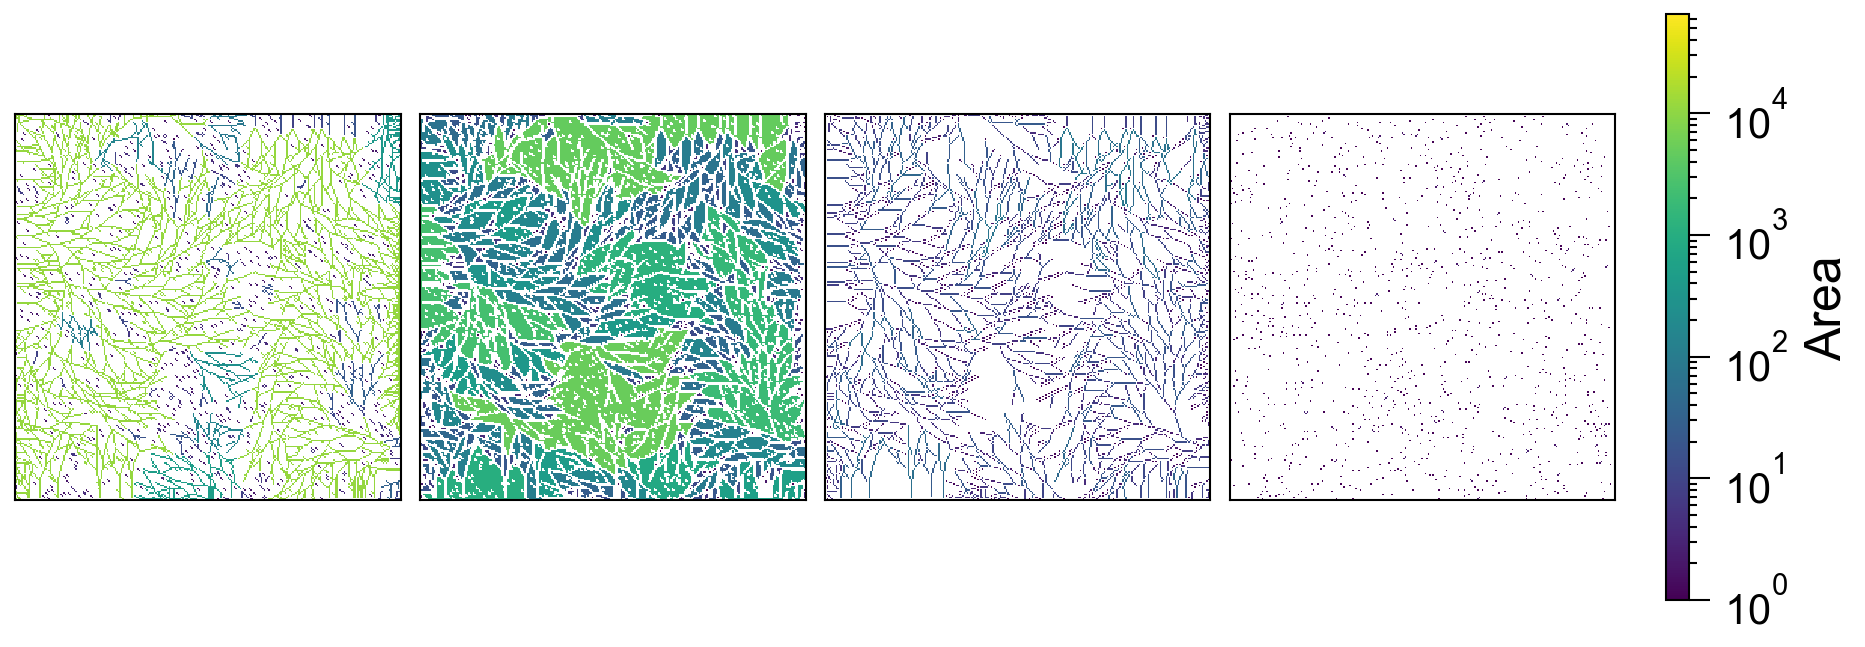

In [53]:
from pylab import *
import scipy.ndimage
from matplotlib.colors import ListedColormap, LogNorm

mask1 = ((image > 0.5) & (image <= 0.65))
mask2 = ((image > 0.65) & (image <= 0.78))
mask3 = ((image > 0.8) & (image <= 0.9))
mask4 = ((image > 0.9))

masks = [mask1, mask2, mask3, mask4]

with plt.style.context(spstyle.get_style('thesis')):

    colors = [plt.cm.viridis(i) for i in range(256)]
    custom_cmap = ListedColormap(colors)
    norm = LogNorm(vmin=1, vmax=L**2)

    fig, axis = plt.subplots(1, 4, figsize=(7.2, 3.8))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    axis = axis.flatten()

    matrix = np.ones((3, 3), dtype=int)

    for ax, mask in zip(axis, masks):

        lw, num = scipy.ndimage.label(mask, structure=matrix)
        area = scipy.ndimage.sum(mask, lw, index=np.arange(lw.max() + 1))

        areaImg = area[lw]
        areaImg[~mask] = 0

        pos = ax.imshow(
            areaImg,
            norm=norm,
            cmap=custom_cmap,
            origin='lower',
            interpolation='nearest'
        )

        print(np.mean(area[1:]))

        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    cbar = fig.colorbar(pos, ax=axis, aspect=25, fraction=0.014, pad=0.03)
    cbar.set_label('Area')

    plt.show()

In [77]:
nb_patch = 100
mean_area = np.zeros(4)

for i in range(nb_patch):
    image = artificial_patch()
    mean_area += perco_analysis(image)
    
print(mean_area/nb_patch)

[28.00339277 60.86018801  5.01150749  1.04726449]


In [78]:
folderpath ="/data1/DATA_Duplat/Brut/Ava_track/Av6n6"
file = f"{folderpath}/shape_outputB10.txt"

L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]
data = []
Nava = []
nbava = 200

with open(file) as f:
    
    for i, line in enumerate(f):
        if line.startswith("#"):
            continue
        col = line.strip().split()[3:]
        id = line.strip().split()[0]
        col = np.array(col, dtype=int)
        y, x = coorno(col, L1)
        """ y = (L1-1) - y """
        
        coo = np.column_stack((x, y))
        data.append(coo.tolist())
        Nava.append(id)
        if i == nbava:
            break



[ 5.9950527  82.25870902  4.86003491  1.20519943]


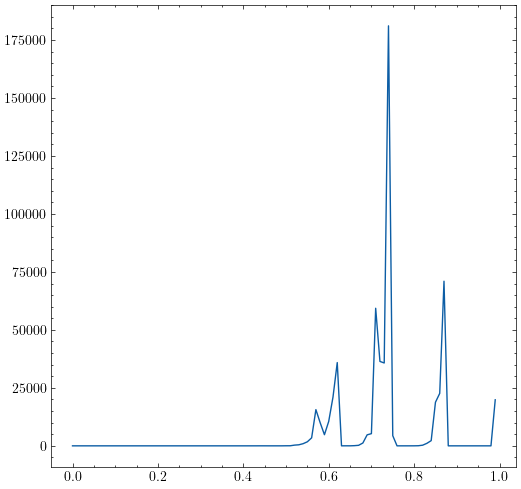

In [ ]:
L1 = 256
L2 = 256

nbins = 100
bins = np.linspace(0,1,nbins+1)
histo = np.zeros(nbins)
mean_area = np.zeros(4)
for i, id in enumerate(Nava):
    sys = np.loadtxt("/data1/DATA_Duplat/Brut/Ava_track/Av6n6/Snapshots/nav{}_outputB.txt".format(id)).reshape(L1, L2)
    
    ava = np.array(data[i])
    y = ava[:,0]
    x = ava[:, 1]
    
    mask = np.zeros_like(sys, dtype = bool)
    mask[y,x] = True
    sysbis = np.where(mask, sys, np.nan)
    
    histo += np.histogram(sysbis, bins = bins)[0]
    mean_area += perco_analysis(sysbis)
    
print(mean_area/len(Nava))
        
        
# fig, ax = plt.subplots(figsize = (6,6))
# ax.plot(bins[:-1], histo)
# plt.show()
